# Bugs — walkthrough

Exercises the C core, the Python wrapper, the interactive controls panel, and the recipe round-trip. Run from the `Bugs/` directory (or with the directory on `sys.path`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

import numpy as np
from python.bugs_py import (Bugs, import_run,
                            plot_food_power_spectrum,
                            plot_move_direction_histogram,
                            plot_egenome_orbit_sweep)
from python.controls import run_with_controls, available_probes

available_probes()

{'G-activity': 'G-activity: whole-genome content-hash strip chart',
 'Gq-activity': 'Gq-activity: G-activity deciles',
 'N-activity': 'N-activity: Channon shadow whole-genome strip chart',
 'Nq-activity': 'Nq-activity: N-activity deciles',
 'g-activity': 'g-activity: per (nbhd, move) LUT-slot strip chart',
 'gq-activity': 'gq-activity: g-activity deciles',
 'egenome': 'Egenome: 9-position strip chart of per-position quantiles',
 'ts': 'Scalar time-series (population, total food-in-bugs)',
 'coloring': 'Bug-coloring: per-LUT-index move distribution (3x3 template)'}

## 1. Smoke test — init, step, free

Construct a `Bugs` instance, initialize a small grid, seed a uniform food source with a bug density, step it a few times headlessly, then free.

In [2]:
sim = Bugs()
sim.init(64, food_inc=0.05, mutation_rate=0.01)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)

print('t=0  pop=', sim.get_population(),
      ' food_env=', round(sim.get_food_env(), 1))

for _ in range(50):
    sim.step()

print(f't={sim.get_step()}  pop={sim.get_population()}'
      f'  food_env={sim.get_food_env():.1f}'
      f'  food_bug={sim.get_food_bug():.1f}')

sim.free()

t=0  pop= 809  food_env= 4096.0
t=50  pop=552  food_env=954.6  food_bug=890.5


## 2. Interactive run with probes

Open the SDL2 window with the ipywidgets control panel and both probes enabled. The cell returns immediately — widgets appear below, the SDL2 window opens in a subprocess, and the simulation runs in a background thread.

In [3]:
sim = Bugs()
sim.init(256, food_inc=0.05, mutation_rate=0.01,move_range=1)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)

run_with_controls(
    sim, cell_px=3,
    probes={'G-activity': True, 'Gq-activity': True,
            'g-activity': True, 'gq-activity': True,
    'ts': True}
)

<Thread(bugs-sim, started daemon 6310604800)>

While the sim is running, cells below still execute — the Jupyter kernel is free. Call `sim.free()` when you're done to close the SDL window and release shared memory.

In [ ]:
sim.free()

## 3. Passing metaparams as a dict

`sim.init(N, **kwargs)` is the only place metaparams go. The constructor (`Bugs(...)`) does **not** take them. To drive from a dict, use `**` unpacking.

**`N` itself can live in the dict** — it binds to the positional `N` parameter. Just don't pass it *both* positionally and in the dict, or you get `TypeError: got multiple values for argument 'N'`.

In [ ]:
params = dict(
    N                 = 256,
    mutation_rate     = 0.005,
    reproduction_food = 30.0,
    movement_cost     = 0.3,
    eat_amount        = 3.0,
    initial_food      = 15.0,
    food_inc          = 0.08,
    mu_egenome        = 0.02,
    gdiff             = 1,
    egenome_init      = [0.1] * 9,   # per-Moore-position food thresholds
)

sim = Bugs()
sim.init(**params)   # N is in the dict, so no positional arg here

print(sim.params_str())   # a round-trip-safe init(...) call

Live-update a metaparam after init via the `update_*` helpers (direct attribute assignment does not propagate to the C library):

In [ ]:
sim.update_food_inc(0.12)
print('food_inc now', sim.food_inc)
sim.free()

## 4. Image-driven food source

`food_source='brightness'` samples a brightness array: pixels with brightness *below* `food_source_thresh` become food (`F_source = 1`), the rest `F_source = 0`. Below, we build a synthetic pattern (ring of food cells) instead of loading a file.

In [10]:
N = 256
yy, xx = np.mgrid[0:N, 0:N]
r = np.sqrt((xx - N/2)**2 + (yy - N/2)**2)
brightness = np.where((r > N*0.38) & (r < N*0.4), 0.0, 1.0).astype(np.float32)
# Dark ring → food; bright interior/exterior → no food.

sim = Bugs()
sim.init(N, food_inc=0.8, mutation_rate=0.01)
sim.state(food_source='brightness', brightness=brightness,
          food_source_thresh=0.5, seed_density=0.15)

run_with_controls(sim, cell_px=3,
                  probes={'G-activity': True, 'Gq-activity': True,
            'g-activity': True, 'gq-activity': True})

<Thread(bugs-sim, started daemon 12969013248)>

In [6]:
N = 256
yy, xx = np.mgrid[0:N, 0:N]
r = np.sqrt((xx - N/2)**2 + (yy - N/2)**2)
brightness = np.where((r > N*0.38) & (r < N*0.4), 0.0, 1.0).astype(np.float32)
# Dark ring → food; bright interior/exterior → no food.

#square:
yy, xx = np.mgrid[0:N, 0:N]
d = np.maximum(np.abs(xx - N/2), np.abs(yy - N/2))   # half-side distance from center
brightness = np.where((d > N/3) & (d < N/3+2), 0.0, 1.0).astype(np.float32)

sim = Bugs()
sim.init(N, food_inc=0.8, mutation_rate=0.1)
sim.state(food_source='brightness', brightness=brightness,
          food_source_thresh=0.5, seed_density=0.15)

run_with_controls(sim, cell_px=3,
                  probes={'G-activity': True, 'Gq-activity': True,
            'g-activity': True, 'gq-activity': True})

<Thread(bugs-sim, started daemon 6356512768)>

In [3]:
sim.free()

Bugs SDL: exiting cleanly
/Users/n/.pyenv/versions/3.14.3/lib/python3.14/multiprocessing/resource_tracker.py:396: UserWarning: resource_tracker: There appear to be 6 leaked shared_memory objects to clean up at shutdown: {'/psm_79f0dcc7', '/psm_0b619d3b', '/psm_52048626', '/psm_fe29845d', '/psm_66308619', '/psm_e0dd60c4'}
  warnings.warn(


In [4]:
import_run()

2026-04-20_basic_with_breathing.bugs
2026-04-20_moore-smoke.bugs
2026-04-21_high_tax_macro_change.bugs
2026-04-21_test.bugs
2026-04-21_walkthrough-demo.bugs


['/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-20_basic_with_breathing.bugs',
 '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-20_moore-smoke.bugs',
 '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_high_tax_macro_change.bugs',
 '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_test.bugs',
 '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_walkthrough-demo.bugs']

## 5. Custom food source from a numpy array

`food_source='custom'` accepts an arbitrary `(N,N)` float array in `[0,1]` and uses it directly as `F_source` (no thresholding).

In [ ]:
N = 128
yy, xx = np.mgrid[0:N, 0:N]
# Diagonal gradient: food plentiful at one corner, scarce at the other.
F_src = ((xx + yy) / (2*N - 2)).astype(np.float32)

sim = Bugs()
sim.init(N, food_inc=0.05, mutation_rate=0.01)
sim.state(food_source='custom', brightness=F_src, seed_density=0.15)

run_with_controls(sim, cell_px=3, colormode=2,
                  probes={'Gq-activity': True, 'gq-activity': True})

In [ ]:
sim.free()

## 6. Seeded reproducibility

Call `sim.set_seed(...)` **before** `sim.state(...)` — `seed_with_density` uses the RNG, so the seed has to be in place when it runs. Two identical-seed runs should produce identical trajectories.

In [ ]:
def run_and_summarize(seed, steps=100):
    s = Bugs()
    s.init(64, food_inc=0.05, mutation_rate=0.01)
    s.set_seed(seed)
    s.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)
    trajectory = []
    for _ in range(steps):
        s.step()
        trajectory.append((s.get_population(), round(s.get_food_env(), 3)))
    s.free()
    return trajectory

a = run_and_summarize(42)
b = run_and_summarize(42)
c = run_and_summarize(43)

print('seed 42 == seed 42  :', a == b)
print('seed 42 == seed 43  :', a == c)
print('last step of seed 42:', a[-1])
print('last step of seed 43:', c[-1])

## 7. Recipes — export and import

`sim.export_recipe(descriptor, ...)` writes a JSON file under `../Runs/` capturing the current metaparams (both the init-time values and any live-edited "final" values), the food-source configuration, seed density, probes, and color mode.

`import_run(filepath, recipe='init'|'final')` rebuilds a fresh `Bugs` instance from that recipe and returns `(sim, display_kwargs)` — `display_kwargs` is ready to splat into `run_with_controls`.

In [4]:
sim = Bugs()
sim.init(96, food_inc=0.06, mutation_rate=0.01, reproduction_food=18.0)
sim.set_seed(1234)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.25)

recipe_path = sim.export_recipe(
    "walkthrough-demo",
    probes={'G-activity': True, 'Gq-activity': True,
            'g-activity': True, 'gq-activity': True},
    colormode=1,
)
sim.free()
print('wrote', recipe_path)

wrote /Users/n/Projects/cocoabugs/Bugs/Runs/2026-05-24_walkthrough-demo.bugs


In [5]:
# List recipes currently under Runs/
foo = import_run()
print(foo)

2026-04-20_basic_with_breathing.bugs
2026-04-20_moore-smoke.bugs
2026-04-21_high_tax_macro_change.bugs
2026-04-21_test.bugs
2026-04-21_test2.bugs
2026-04-21_walkthrough-demo.bugs
2026-04-23_genome_weirdness_24K.bugs
2026-05-24_walkthrough-demo.bugs
['/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-20_basic_with_breathing.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-20_moore-smoke.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_high_tax_macro_change.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_test.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_test2.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_walkthrough-demo.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-23_genome_weirdness_24K.bugs', '/Users/n/Projects/cocoabugs/Bugs/Runs/2026-05-24_walkthrough-demo.bugs']


In [6]:
foo[-2]

'/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-23_genome_weirdness_24K.bugs'

In [7]:
sim.free()
recipe_path = foo[-2]

In [8]:
recipe_path='/Users/n/Projects/cocoabugs/Bugs/Runs/2026-04-21_test2.bugs'
sim, display_kwargs = import_run(recipe_path,recipe='final')
print(sim.params_str())
print('display kwargs:', display_kwargs)

run_with_controls(sim, cell_px=3, **display_kwargs)

recipe 2026-04-21_test2.bugs: explored params  (using final)
    initial_food          init=10.0  →  final=10.000000000000002
    reproduction_food     init=20.0  →  final=19.999999999999996
sim.init(
    N=256,
    mutation_rate=0.1,   # default: 0.02
    reproduction_food=19.999999999999996,   # default: 20.0
    movement_cost=0.5,
    eat_amount=2.0,
    initial_food=10.000000000000002,   # default: 10.0
    food_inc=0.8,   # default: 0.01
    mu_egenome=0.0,
    gdiff=0,
    move_range=15,
    egenome_init=[0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612],
)
display kwargs: {'probes': {'G-activity': True, 'Gq-activity': True, 'g-activity': True, 'gq-activity': True}}


<Thread(bugs-sim, started daemon 6310604800)>

Bugs SDL: starting  N=256 px=3  G-activity=True  Gq-activity=True  N-activity=False  Nq-activity=False  g-activity=True  gq-activity=True  egenome=False  ts=False  coloring=False


In [ ]:
sim.free()

## 8. Programmatic probe access

Probes can be read directly without the display, which is useful for headless experiments. `get_G_activity()` returns the per-genome hash table as numpy arrays; `Gq_activity_deciles()` returns the 9 population-activity deciles p10..p90.

In [9]:
sim = Bugs()
sim.init(64, food_inc=0.08, mutation_rate=0.005)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)

for _ in range(200):
    sim.step()
    sim.G_activity_update()

tbl = sim.get_G_activity()
order = np.argsort(-tbl['activity'])[:10]
print(f"Top 10 genomes by cumulative activity (of {len(tbl['hash'])} distinct):\n")
print(f"  {'hash':>10}  {'activity':>10}  {'pop_count':>10}")
for i in order:
    print(f"  0x{tbl['hash'][i]:08x}  {tbl['activity'][i]:>10}  "
          f"{tbl['pop_count'][i]:>10}")

print('\nq_activity deciles (p10..p90):', sim.Gq_activity_deciles())
sim.free()

Top 10 genomes by cumulative activity (of 801 distinct):

        hash    activity   pop_count
  0x37ccb7f9         200           1
  0x7c7be987         200           1
  0x5af42989         200           1
  0xda70b98f         200           1
  0x2ff57991         200           1
  0x19c929aa         200           1
  0xeec0e9b6         200           1
  0x0296c987         200           1
  0x8f8ff9bf         200           1
  0x148d89c3         200           1

q_activity deciles (p10..p90): [0.43103448 0.43103448 0.43103448 0.43103448 0.43103448 0.43103448
 0.43103448 0.43103448 0.43103448]


### G‑activity vs g‑activity

`G` is per whole‑genome (content hash); `g` is per `(input, output)` LUT‑slot motif. Compare top G‑buckets (distinct genomes) to top g‑buckets (distinct motifs) after a short run.


In [ ]:
sim = Bugs()
sim.init(64, food_inc=0.08, mutation_rate=0.005)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)

for _ in range(200):
    sim.step()
    sim.G_activity_update()
    sim.g_activity_update()

G = sim.get_G_activity()
g = sim.get_g_activity(max_n=200000)
print(f'distinct genomes (G buckets):       {len(G["hash"])}')
print(f'distinct (nbhd,dx,dy) motifs (g):    {len(g["key"])}')
print(f'Gq deciles p10..p90: {sim.Gq_activity_deciles()}')
print(f'gq deciles p10..p90: {sim.gq_activity_deciles()}')
sim.free()


## 9. Moore neighborhood — 512 genes and the bug-coloring histogram

The C core uses a 9-bit Moore neighborhood, so each bug has **512** genes (up from 32 in the Obj-C original). `bug_coloring_hist(gene_idx)` returns a 31×31 histogram of per-bug `(dx, dy)` outputs at the given LUT index — the same signal the interactive `coloring` probe plots.

Sanity-check: with enough mutation, the total count across the histogram should equal the live population, and the sum over all LUT indices should equal `pop × 512`.

In [10]:
from python.bugs_py import N_GENES, NBHD
print('NBHD      =', NBHD)
print('N_GENES   =', N_GENES)

sim = Bugs()
sim.init(64, food_inc=0.08, mutation_rate=0.02)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)
for _ in range(50):
    sim.step()

pop = sim.get_population()
idx = 0b000010000                # center bit only (C=self)
hist = sim.bug_coloring_hist(idx)
print(f'\npop = {pop}')
print(f'hist[lut_idx={idx}]  shape={hist.shape}  sum={int(hist.sum())}')
assert hist.shape == (31, 31)
assert int(hist.sum()) == pop    # one (dx,dy) per bug

total = sum(int(sim.bug_coloring_hist(i).sum()) for i in range(N_GENES))
print(f'sum over all {N_GENES} LUT indices = {total}   (expect pop*N_GENES = {pop*N_GENES})')
sim.free()

NBHD      = moore
N_GENES   = 512

pop = 791
hist[lut_idx=16]  shape=(31, 31)  sum=791
sum over all 512 LUT indices = 404992   (expect pop*N_GENES = 404992)


## 10. Built-in PNG food templates

`food_source='template'` + `template=<name>` loads one of the PNGs bundled with the original CocoaBugs distribution, resized to the current `N`. The threshold (`food_source_thresh`) behaves as for `'brightness'`: pixels darker than it become food. `food_templates()` enumerates the bundled names.

In [15]:
from python.bugs_py import food_templates
print('bundled templates:', food_templates())

sim = Bugs()
sim.init(512, food_inc=0.8, mutation_rate=0.1,movement_cost=0.8)
sim.state(food_source='template', template='empty_boxes',
          food_source_thresh=0.5, seed_density=0.15)

run_with_controls(
    sim, cell_px=2,
    probes={'G-activity': True, 'Gq-activity': True,
            'g-activity': True, 'gq-activity': True,
#            'ts': True, 'coloring': True},
            'coloring': True},
)

bundled templates: {'stripes': '/Users/n/Projects/cocoabugs/CocoaBugs/Stripes.png', 'r-pentomino': '/Users/n/Projects/cocoabugs/CocoaBugs/R-pentomino.png', 'big_box': '/Users/n/Projects/cocoabugs/CocoaBugs/Big box.png', '3x3_boxes': '/Users/n/Projects/cocoabugs/CocoaBugs/3x3 boxes.png', 'empty_boxes': '/Users/n/Projects/cocoabugs/CocoaBugs/Empty boxes.png'}


<Thread(bugs-sim, started daemon 6361083904)>

In [ ]:
sim.free()

## 11. Recipe v2 nbhd compatibility

Recipe files now carry `version`, `nbhd`, and `n_genes` fields. `import_run()` rejects a recipe whose `nbhd` doesn't match the running C core, so a VN-era 32-gene recipe can't silently be replayed against the Moore runtime.

In [11]:
import json, tempfile, os

sim = Bugs()
sim.init(64, food_inc=0.05)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.1)
path = sim.export_recipe('nbhd-roundtrip')
sim.free()

with open(path) as f:
    rec = json.load(f)
print('version =', rec.get('version'), ' nbhd =', rec.get('nbhd'),
      ' n_genes =', rec.get('n_genes'))

# Round-trip the matching recipe — should succeed.
sim2, kw = import_run(path)
print('round-trip ok, params:', sim2.params_str())
sim2.free()

# Now tamper with the nbhd field and confirm import_run refuses to load it.
bad = dict(rec, nbhd='vonneumann', n_genes=32)
bad_path = os.path.join(tempfile.gettempdir(), 'bad_nbhd.bugs')
with open(bad_path, 'w') as f:
    json.dump(bad, f)
try:
    import_run(bad_path)
except ValueError as e:
    print('guard fired as expected:', e)

version = 3  nbhd = moore  n_genes = 512
round-trip ok, params: sim.init(
    N=64,
    mutation_rate=0.02,
    reproduction_food=20.0,
    movement_cost=0.5,
    eat_amount=2.0,
    initial_food=10.0,
    food_inc=0.05,   # default: 0.01
    mu_egenome=0.0,
    gdiff=0,
    move_range=15,
    egenome_init=[0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612, 0.10000000149011612],
)
guard fired as expected: recipe '/var/folders/gl/c2ypjywd5zd7__1lddcg09cw0000gs/T/bad_nbhd.bugs' was written for nbhd='vonneumann' (n_genes=32) but the current build is nbhd='moore' (n_genes=512). Recipes are not transferable across neighborhood topologies — genome structure differs.


## 12. Egenome — per-position food thresholds with Gaussian drift

Each bug carries a length-9 `egenome` — one food threshold per Moore-neighborhood position (`[NW, N, NE, W, C, E, SW, S, SE]`). The perception bit for position *p* is `F(neighbor_p) > egenome[p]`. At birth, the child's egenome is the parent's with i.i.d. truncated-Gaussian drift of width `mu_egenome` per entry, clipped to `[0, 1]`.

With `mu_egenome = 0`, children copy exactly — the egenome is a static parameter. With `mu_egenome > 0`, perception itself evolves.

Three initialization helpers: `egenome_center_only` (only the center cell is perceived), `egenome_constant` (uniform threshold on all 9 positions; reproduces the historical scalar `food_threshold`), and `egenome_random` (i.i.d. uniform).

In [12]:
from python.bugs_py import (
    egenome_center_only, egenome_constant, egenome_random,
)

sim = Bugs()
sim.init(96, food_inc=0.08, mutation_rate=0.01, mu_egenome=0.02)
sim.state(food_source='uniform', food_source_value=1.0,
          seed_density=0.2,
          egenome_init=egenome_constant(0.3))

m0, s0 = sim.egenome_stats()
print(f't=0   mean={m0}  std={s0}')

for _ in range(400):
    sim.step()

m1, s1 = sim.egenome_stats()
print(f't=400 mean={np.round(m1, 3)}')
print(f'       std={np.round(s1, 3)}')
print(f'       pop={sim.get_population()}')
sim.free()

t=0   mean=[0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]  std=[0. 0. 0. 0. 0. 0. 0. 0. 0.]
t=400 mean=[0.3   0.3   0.3   0.3   0.3   0.3   0.3   0.301 0.3  ]
       std=[0.01  0.01  0.01  0.009 0.009 0.009 0.009 0.009 0.009]
       pop=1311


# Diag for asymmetry

In [13]:
fig, info = plot_food_power_spectrum(sim,100,1);
print(info['asymmetry'])

ValueError: NULL pointer access

In [3]:
sim = Bugs()
sim.init(256, food_inc=0.05, mutation_rate=0.01,move_range=1)

foo = []
for k in range(50):
    sim.set_seed(k)
    sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)
    for i in range(400):
        sim.step()
    fig, info = plot_food_power_spectrum(sim,100,1,show=False)
    foo.append(info['asymmetry'])
    print('.',end="")

..................................................

In [4]:
from matplotlib import pyplot as plt

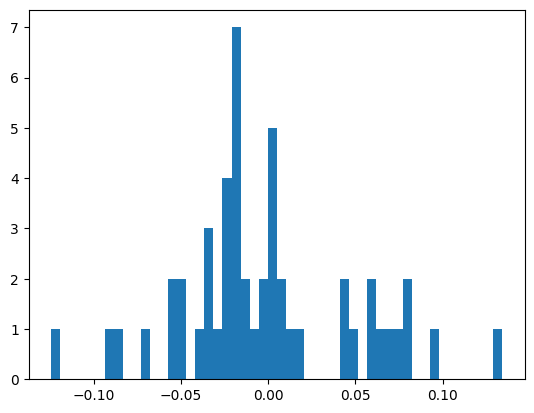

In [5]:
plt.hist(foo,bins=50);

In [13]:
np.mean(foo)

np.float64(0.0008558758133335232)

axis_asym = 0.02828759050345176
diag_asym = 0.005381240168888153
total     = 23957


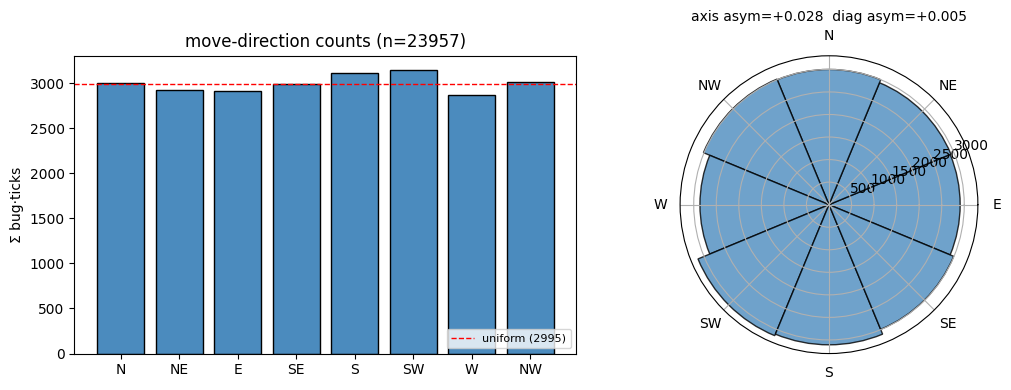

In [6]:
sim = Bugs()
sim.init(128, food_inc=0.05, mutation_rate=0.01, move_range=1)
sim.set_seed(0)
sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)
for _ in range(300):
    sim.step()
fig, info = plot_move_direction_histogram(sim, num_frames=20)
print('axis_asym =', info['axis_asym'])
print('diag_asym =', info['diag_asym'])
print('total     =', info['total'])
sim.free()

In [7]:
sim = Bugs()
sim.init(128, food_inc=0.05, mutation_rate=0.01, move_range=1)

axis_asyms, diag_asyms = [], []
for k in range(20):
    sim.set_seed(k)
    sim.state(food_source='uniform', food_source_value=1.0, seed_density=0.2)
    for _ in range(300):
        sim.step()
    fig, info = plot_move_direction_histogram(sim, num_frames=20, show=False)
    axis_asyms.append(info['axis_asym'])
    diag_asyms.append(info['diag_asym'])
    print('.', end='')
print()
print(f'axis_asym  mean={np.mean(axis_asyms):+.4f}  std={np.std(axis_asyms):.4f}')
print(f'diag_asym  mean={np.mean(diag_asyms):+.4f}  std={np.std(diag_asyms):.4f}')
sim.free()

....................
axis_asym  mean=+0.0010  std=0.0171
diag_asym  mean=-0.0000  std=0.0180
